<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-07-24 08:26:15--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  36.7MB/s    in 5.4s    

2026-07-24 08:26:21 (37.2 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 122.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 147.1 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 128.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 115.7 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


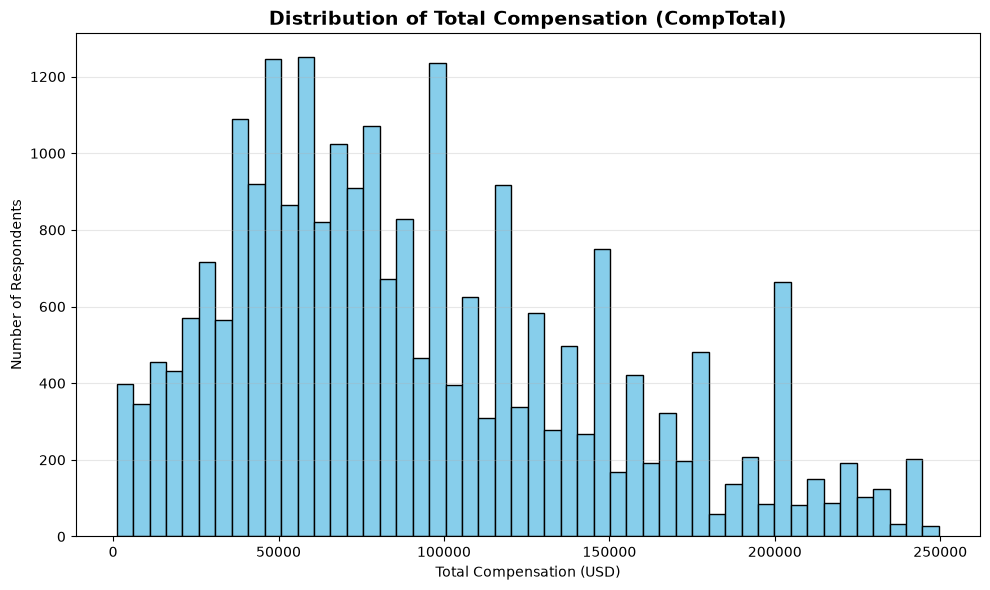

Median: $80,000.00
Mean: $92,292.71
Count: 24779


In [9]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("survey-data.csv")

# 1. Clean CompTotal - very important, file has outliers
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df_comp = df['CompTotal'].dropna()

# Remove extreme outliers for better visualization (IBM teaches this)
# Most salaries are < 200k, but file has 10M+ values
df_comp_filtered = df_comp[(df_comp > 1000) & (df_comp < 250000)]

# 2. Histogram
plt.figure(figsize=(10,6))
plt.hist(df_comp_filtered, bins=50, color='skyblue', edgecolor='black')

plt.title('Distribution of Total Compensation (CompTotal)', fontsize=14, fontweight='bold')
plt.xlabel('Total Compensation (USD)')
plt.ylabel('Number of Respondents')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: print stats
print(f"Median: ${df_comp_filtered.median():,.2f}")
print(f"Mean: ${df_comp_filtered.mean():,.2f}")
print(f"Count: {len(df_comp_filtered)}")

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


<StringArray>
[                 nan,                 '17',                 '27',
                  '7',                 '11',                 '25',
                 '12',                 '10',                  '3',
   'Less than 1 year',                 '18',                 '37',
                 '15',                 '20',                  '6',
                  '2',                 '16',                  '8',
                 '14',                  '4',                 '45',
                  '1',                 '24',                 '29',
                  '5',                 '30',                 '26',
                  '9',                 '33',                 '13',
                 '35',                 '23',                 '22',
                 '31',                 '19',                 '21',
                 '28',                 '34',                 '32',
                 '40',                 '50',                 '39',
                 '44',                 '42',    

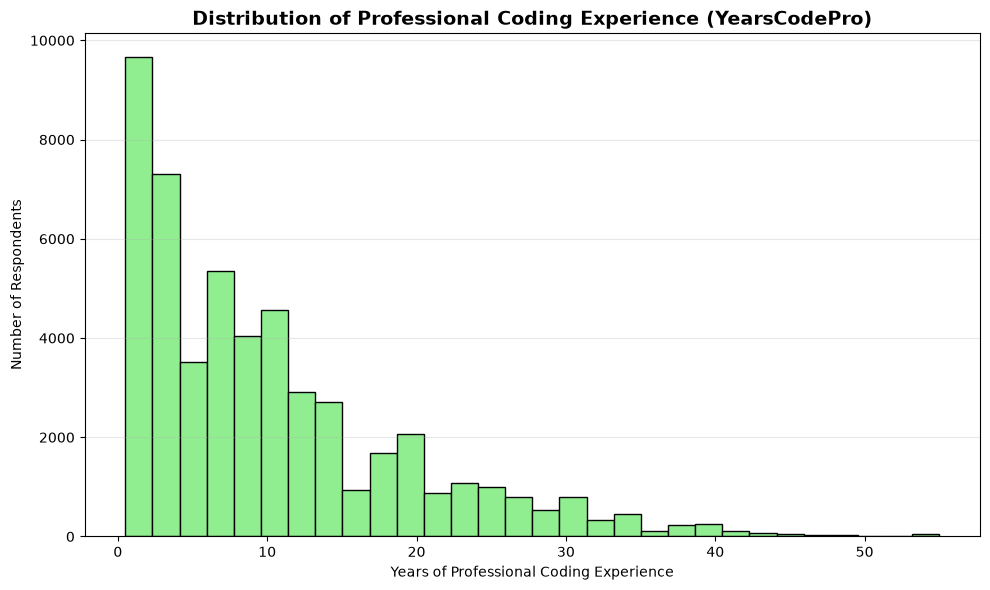

Median experience: 7.0 years
Most common: 2.0 years


In [10]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("survey-data.csv")

# Show unique values
print(df['YearsCodePro'].unique())

# ---- Convert YearsCodePro text to numbers ----
def map_years(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if 'Less than 1 year' in val:
        return 0.5
    if 'More than 50' in val:
        return 55
    # Extract first number: "5", "10", etc
    import re
    m = re.search(r'(\d+)', val)
    return float(m.group(1)) if m else np.nan

df['YearsCodePro_num'] = df['YearsCodePro'].apply(map_years)
df_years = df['YearsCodePro_num'].dropna()

# ---- Histogram ----
plt.figure(figsize=(10,6))
plt.hist(df_years, bins=30, color='lightgreen', edgecolor='black')

plt.title('Distribution of Professional Coding Experience (YearsCodePro)', fontsize=14, fontweight='bold')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Number of Respondents')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Median experience: {df_years.median()} years")
print(f"Most common: {df_years.mode().values[0]} years")

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


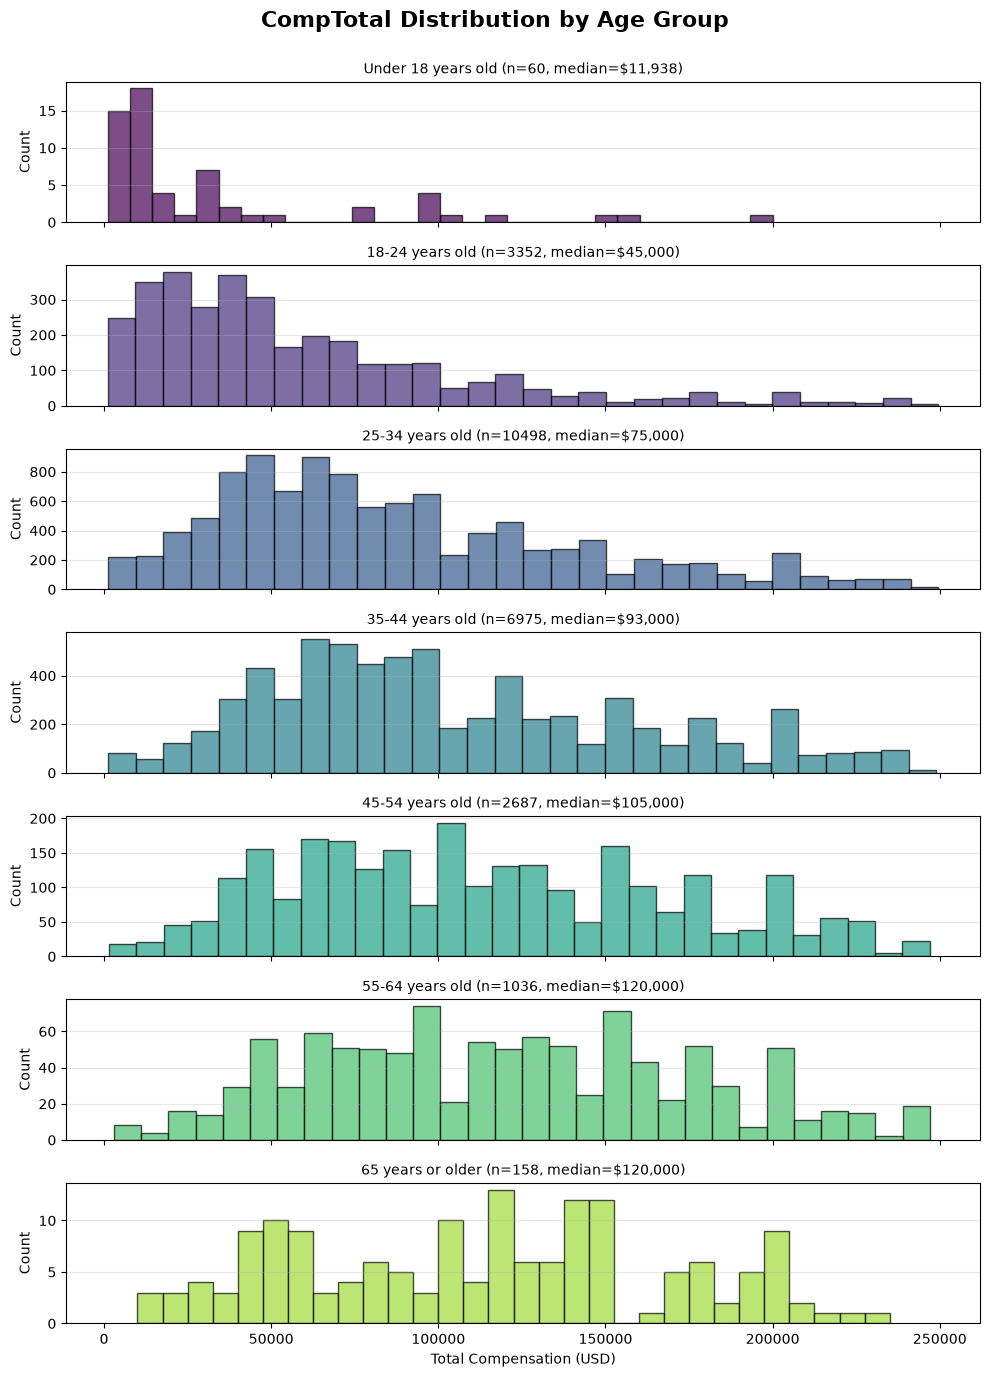

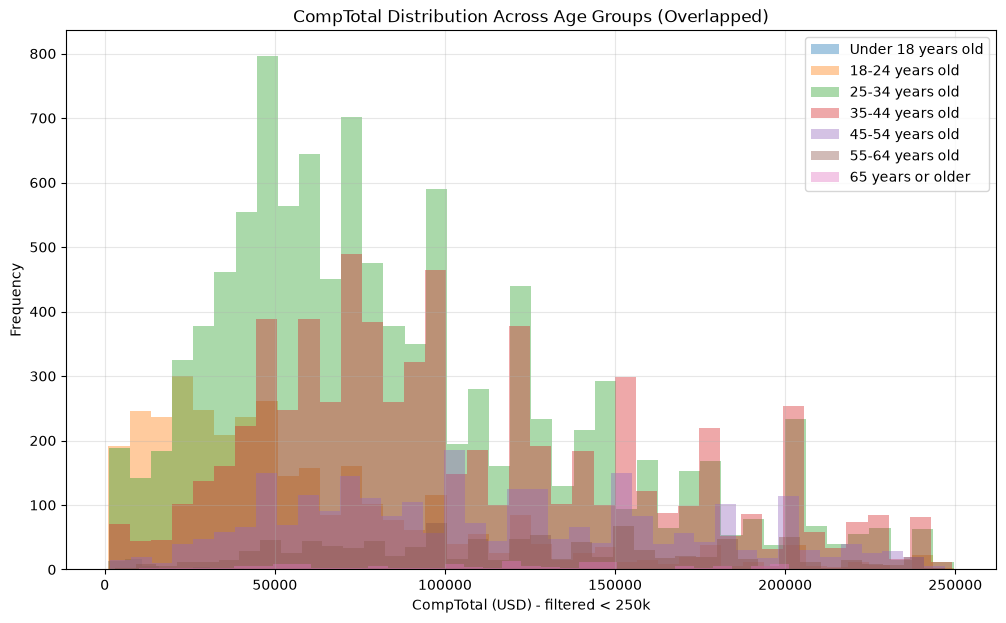

In [11]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("survey-data.csv")

# Clean CompTotal
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
# Remove extreme outliers for readable histogram
df_clean = df[(df['CompTotal'] > 1000) & (df['CompTotal'] < 250000)].dropna(subset=['CompTotal', 'Age'])

# Get age groups in order
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old',
             '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']
existing_ages = [a for a in age_order if a in df_clean['Age'].unique()]

# ---- Histogram per Age Group - Subplots ----
fig, axes = plt.subplots(len(existing_ages), 1, figsize=(10, 14), sharex=True)
fig.suptitle('CompTotal Distribution by Age Group', fontsize=16, fontweight='bold')

for i, age in enumerate(existing_ages):
    data = df_clean[df_clean['Age'] == age]['CompTotal']
    axes[i].hist(data, bins=30, color=plt.cm.viridis(i/len(existing_ages)), edgecolor='black', alpha=0.7)
    axes[i].set_title(f"{age} (n={len(data)}, median=${data.median():,.0f})", fontsize=10)
    axes[i].set_ylabel('Count')
    axes[i].grid(axis='y', alpha=0.3)

axes[-1].set_xlabel('Total Compensation (USD)')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# ---- Alternative: Overlapped Histogram in one plot ----
plt.figure(figsize=(12,7))
for age in existing_ages:
    data = df_clean[df_clean['Age'] == age]['CompTotal']
    plt.hist(data, bins=40, alpha=0.4, label=age)

plt.title('CompTotal Distribution Across Age Groups (Overlapped)')
plt.xlabel('CompTotal (USD) - filtered < 250k')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [ ]:
## Write your code here

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("survey-data.csv")

# ---- 1. Clean TimeSearching -> numbers ----
time_map = {
    'Less than 15 minutes a day': 0.25,
    '15-30 minutes a day': 0.5,
    '30-60 minutes a day': 0.75,
    '60-120 minutes a day': 1.5,
    'Over 120 minutes a day': 2.5
}

def map_time(s):
    if pd.isna(s): return None
    s = str(s).strip()
    if s in time_map:
        return time_map[s]
    # fallback - factorize if wording different
    return None

df['TimeSearching_num'] = df['TimeSearching'].apply(map_time)
# If map failed (all None), use factorize
if df['TimeSearching_num'].isna().all():
    df['TimeSearching_num'] = pd.factorize(df['TimeSearching'])[0]

df_clean = df.dropna(subset=['TimeSearching_num', 'Age'])

# ---- 2. Ordered Age groups ----
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old',
             '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']
existing_ages = [a for a in age_order if a in df_clean['Age'].unique()]

# ---- 3. Histograms per Age - Subplots ----
fig, axes = plt.subplots(len(existing_ages), 1, figsize=(10, 13), sharex=True)
fig.suptitle('TimeSearching Distribution by Age Group', fontsize=16, fontweight='bold')

for i, age in enumerate(existing_ages):
    data = df_clean[df_clean['Age'] == age]['TimeSearching_num']
    axes[i].hist(data, bins=5, color=plt.cm.plasma(i/len(existing_ages)), edgecolor='black', rwidth=0.8)
    axes[i].set_title(f"{age} (n={len(data)})")
    axes[i].set_ylabel('Count')
    axes[i].set_xticks([0.25, 0.5, 0.75, 1.5, 2.5])
    axes[i].set_xticklabels(['<15m', '15-30m', '30-60m', '60-120m', '>120m'])

axes[-1].set_xlabel('Time Spent Searching per Day (hours)')
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

# ---- 4. Overlapped version (easier to compare) ----
plt.figure(figsize=(12,6))
for age in existing_ages:
    data = df_clean[df_clean['Age'] == age]['TimeSearching_num']
    plt.hist(data, bins=5, alpha=0.5, label=age)

plt.title('TimeSearching Across Age Groups (Overlapped)')
plt.xlabel('Time Searching')
plt.ylabel('Count')
plt.legend()
plt.show()


### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


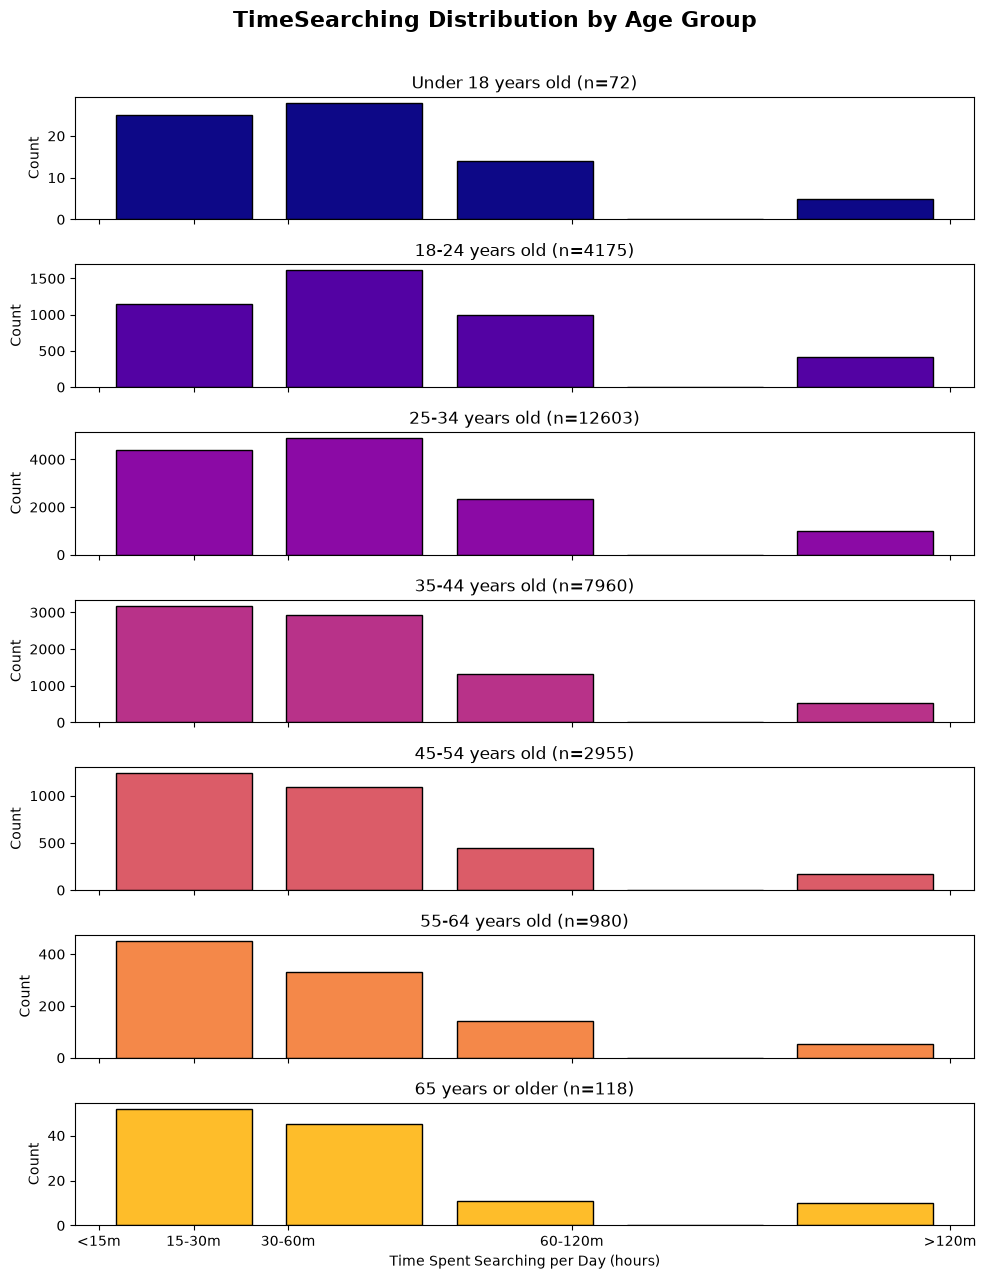

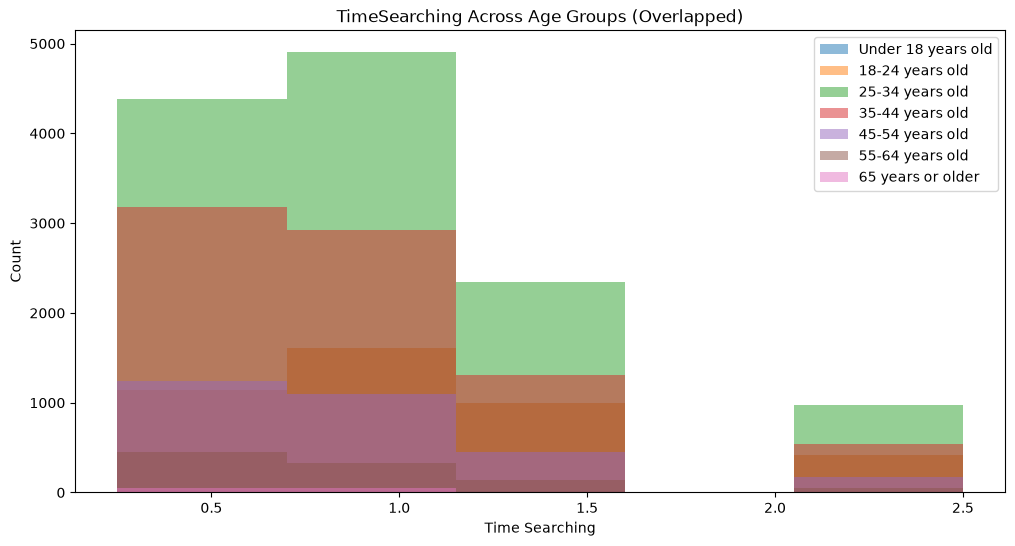

In [12]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("survey-data.csv")

# ---- 1. Clean TimeSearching -> numbers ----
time_map = {
    'Less than 15 minutes a day': 0.25,
    '15-30 minutes a day': 0.5,
    '30-60 minutes a day': 0.75,
    '60-120 minutes a day': 1.5,
    'Over 120 minutes a day': 2.5
}

def map_time(s):
    if pd.isna(s): return None
    s = str(s).strip()
    if s in time_map:
        return time_map[s]
    # fallback - factorize if wording different
    return None

df['TimeSearching_num'] = df['TimeSearching'].apply(map_time)
# If map failed (all None), use factorize
if df['TimeSearching_num'].isna().all():
    df['TimeSearching_num'] = pd.factorize(df['TimeSearching'])[0]

df_clean = df.dropna(subset=['TimeSearching_num', 'Age'])

# ---- 2. Ordered Age groups ----
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old',
             '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']
existing_ages = [a for a in age_order if a in df_clean['Age'].unique()]

# ---- 3. Histograms per Age - Subplots ----
fig, axes = plt.subplots(len(existing_ages), 1, figsize=(10, 13), sharex=True)
fig.suptitle('TimeSearching Distribution by Age Group', fontsize=16, fontweight='bold')

for i, age in enumerate(existing_ages):
    data = df_clean[df_clean['Age'] == age]['TimeSearching_num']
    axes[i].hist(data, bins=5, color=plt.cm.plasma(i/len(existing_ages)), edgecolor='black', rwidth=0.8)
    axes[i].set_title(f"{age} (n={len(data)})")
    axes[i].set_ylabel('Count')
    axes[i].set_xticks([0.25, 0.5, 0.75, 1.5, 2.5])
    axes[i].set_xticklabels(['<15m', '15-30m', '30-60m', '60-120m', '>120m'])

axes[-1].set_xlabel('Time Spent Searching per Day (hours)')
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

# ---- 4. Overlapped version (easier to compare) ----
plt.figure(figsize=(12,6))
for age in existing_ages:
    data = df_clean[df_clean['Age'] == age]['TimeSearching_num']
    plt.hist(data, bins=5, alpha=0.5, label=age)

plt.title('TimeSearching Across Age Groups (Overlapped)')
plt.xlabel('Time Searching')
plt.ylabel('Count')
plt.legend()
plt.show()


**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith',

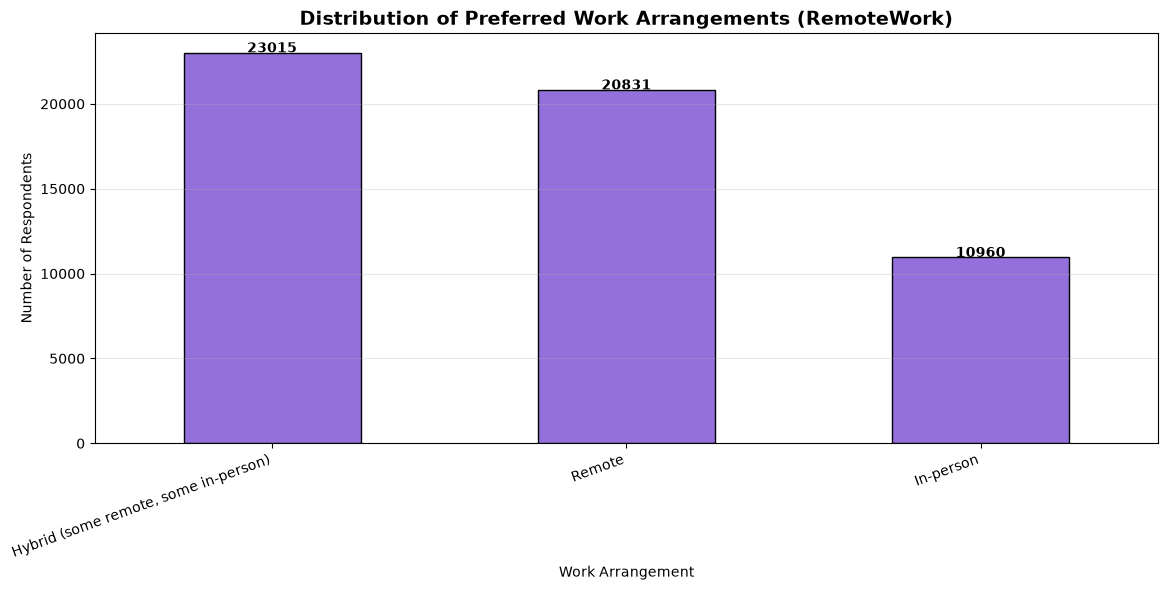

In [13]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("survey-data.csv")

# Check which column exists
print(df.columns.tolist())

# Auto-find remote work column
possible_cols = ['WorkLoc', 'WorkLocation', 'RemoteWork', 'WorkLocationPreference', 'Remote']
remote_col = next((c for c in possible_cols if c in df.columns), None)

if remote_col:
    print(f"Using column: {remote_col}")
    print(df[remote_col].value_counts())
    
    counts = df[remote_col].value_counts()

    # Histogram (bar chart for categories)
    plt.figure(figsize=(12,6))
    counts.plot(kind='bar', color='mediumpurple', edgecolor='black')
    
    plt.title(f'Distribution of Preferred Work Arrangements ({remote_col})', fontsize=14, fontweight='bold')
    plt.xlabel('Work Arrangement')
    plt.ylabel('Number of Respondents')
    plt.xticks(rotation=20, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    # Add counts on top
    for i, v in enumerate(counts):
        plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    # Fallback - if no WorkLoc, use Employment + MainBranch
    print("No WorkLoc column found, using WorkLocation check")
    print(df['Employment'].value_counts().head())

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


Mid-career 45-60 respondents: 3723
count      3723.000000
mean     114873.149342
std       55765.083286
min        1500.000000
25%       70000.000000
50%      110000.000000
75%      153500.000000
max      247000.000000
Name: CompTotal, dtype: float64


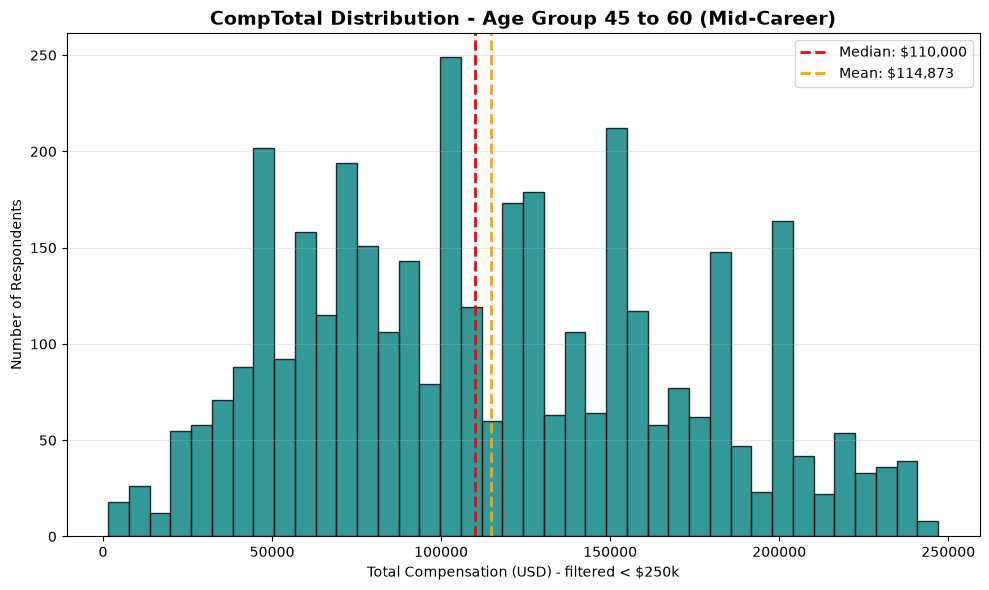

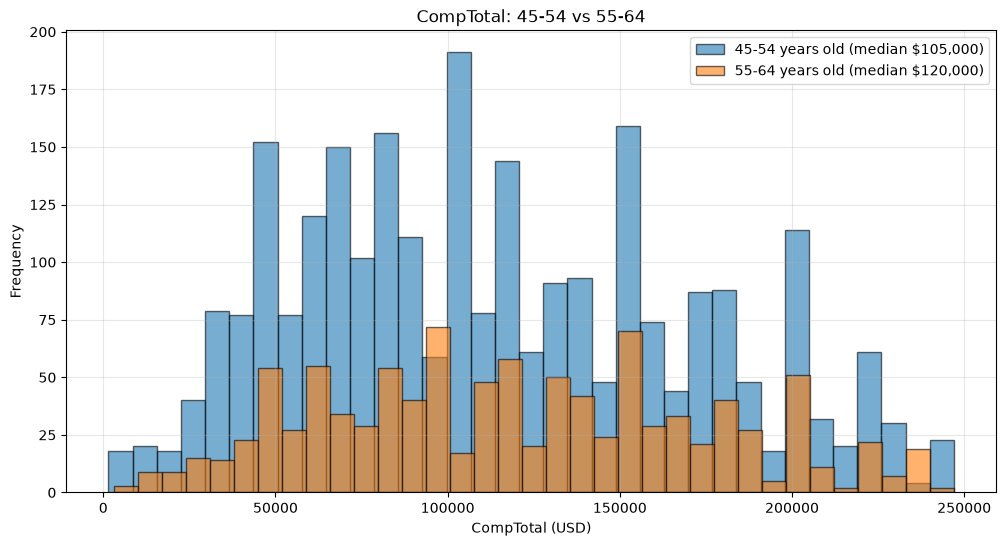

In [14]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("survey-data.csv")

# 1. Clean CompTotal
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# 2. Filter Age 45 to 60
# File has '45-54 years old' and '55-64 years old'
age_groups_45_60 = ['45-54 years old', '55-64 years old', '45-60 years old']
existing = [a for a in age_groups_45_60 if a in df['Age'].unique()]

df_mid = df[df['Age'].isin(existing)].copy()

# Remove outliers for readable histogram (IBM files have $10M salaries)
df_mid_clean = df_mid[(df_mid['CompTotal'] > 1000) & (df_mid['CompTotal'] < 250000)].dropna(subset=['CompTotal'])

print(f"Mid-career 45-60 respondents: {len(df_mid_clean)}")
print(df_mid_clean['CompTotal'].describe())

# 3. Histogram
plt.figure(figsize=(10,6))
plt.hist(df_mid_clean['CompTotal'], bins=40, color='teal', edgecolor='black', alpha=0.8)

plt.title('CompTotal Distribution - Age Group 45 to 60 (Mid-Career)', fontsize=14, fontweight='bold')
plt.xlabel('Total Compensation (USD) - filtered < $250k')
plt.ylabel('Number of Respondents')
plt.axvline(df_mid_clean['CompTotal'].median(), color='red', linestyle='--', linewidth=2, label=f"Median: ${df_mid_clean['CompTotal'].median():,.0f}")
plt.axvline(df_mid_clean['CompTotal'].mean(), color='orange', linestyle='--', linewidth=2, label=f"Mean: ${df_mid_clean['CompTotal'].mean():,.0f}")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Separate by 45-54 vs 55-64 (better insight)
if len(existing) > 1:
    plt.figure(figsize=(12,6))
    for age in existing:
        data = df_mid_clean[df_mid_clean['Age'] == age]['CompTotal']
        plt.hist(data, bins=35, alpha=0.6, label=f"{age} (median ${data.median():,.0f})", edgecolor='black')
    
    plt.title('CompTotal: 45-54 vs 55-64')
    plt.xlabel('CompTotal (USD)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


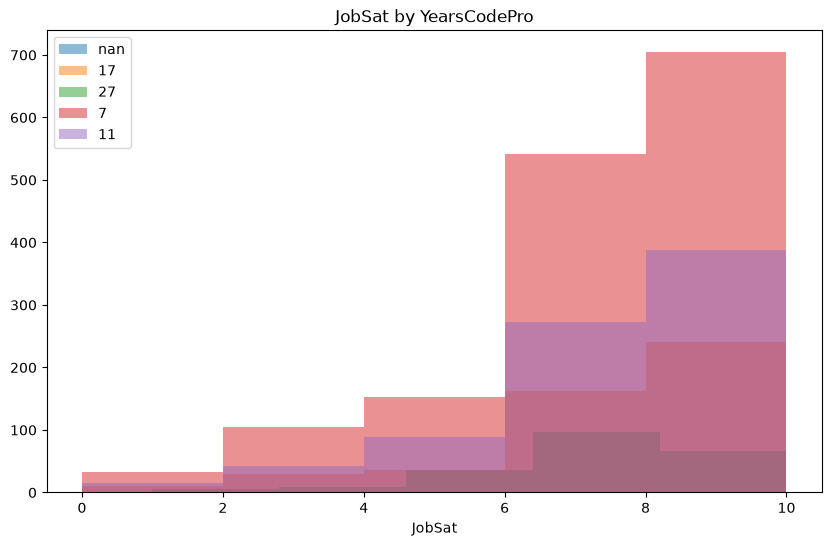

In [17]:
plt.figure(figsize=(10,6))
for years in df['YearsCodePro'].unique()[:5]: # top 5 groups
    subset = df[df['YearsCodePro'] == years]['JobSat'].dropna()
    plt.hist(subset, bins=5, alpha=0.5, label=str(years))
plt.legend()
plt.xlabel('JobSat')
plt.title('JobSat by YearsCodePro')
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [ ]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
